# III: Frequentist Inference


**Question:** Is there a statistically significant difference between the mean GPA of scholarship students and non-scholarship students in the wider student population?

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
# Load the prepared dataset
data = pd.read_csv("../data/prepared_student_data.csv")

# Split into the two groups of interest
scholarship = data[data['scholarship_yes'] == 1]['cumulative_gpa']
non_scholarship = data[data['scholarship_yes'] == 0]['cumulative_gpa']

print(f"Scholarship students:     n = {len(scholarship)}, mean GPA = {scholarship.mean():.4f}, std = {scholarship.std():.4f}")
print(f"Non-scholarship students: n = {len(non_scholarship)}, mean GPA = {non_scholarship.mean():.4f}, std = {non_scholarship.std():.4f}")
print(f"\nObserved difference in means (scholarship - non-scholarship): {scholarship.mean() - non_scholarship.mean():.4f}")

Scholarship students:     n = 523, mean GPA = 3.2054, std = 0.9065
Non-scholarship students: n = 670, mean GPA = 3.1347, std = 0.6001

Observed difference in means (scholarship - non-scholarship): 0.0708


### Normal Approximation Confidence Interval

With group sizes of over 500 students each, the Central Limit Theorem ensures the sampling distribution of the mean difference is approximately normal. This lets us use a simple **z-interval** to construct a 95% CI for the true difference in mean GPA.

In [10]:
# --- Normal approximation confidence interval ---

n_s  = len(scholarship)
n_ns = len(non_scholarship)

mean_diff = scholarship.mean() - non_scholarship.mean()
se_diff   = np.sqrt(scholarship.var(ddof=1)/n_s + non_scholarship.var(ddof=1)/n_ns)

z_crit  = 1.96  # 95% CI, two-tailed
ci_low  = mean_diff - z_crit * se_diff
ci_high = mean_diff + z_crit * se_diff

print(f"Observed mean GPA difference (scholarship - non-scholarship): {mean_diff:.4f}")
print(f"Standard error of the difference:                            {se_diff:.4f}")
print(f"\n95% Normal Approximation CI: ({ci_low:.4f}, {ci_high:.4f})")

Observed mean GPA difference (scholarship - non-scholarship): 0.0708
Standard error of the difference:                            0.0459

95% Normal Approximation CI: (-0.0192, 0.1608)


### Visualizing the Normal Approximation CI

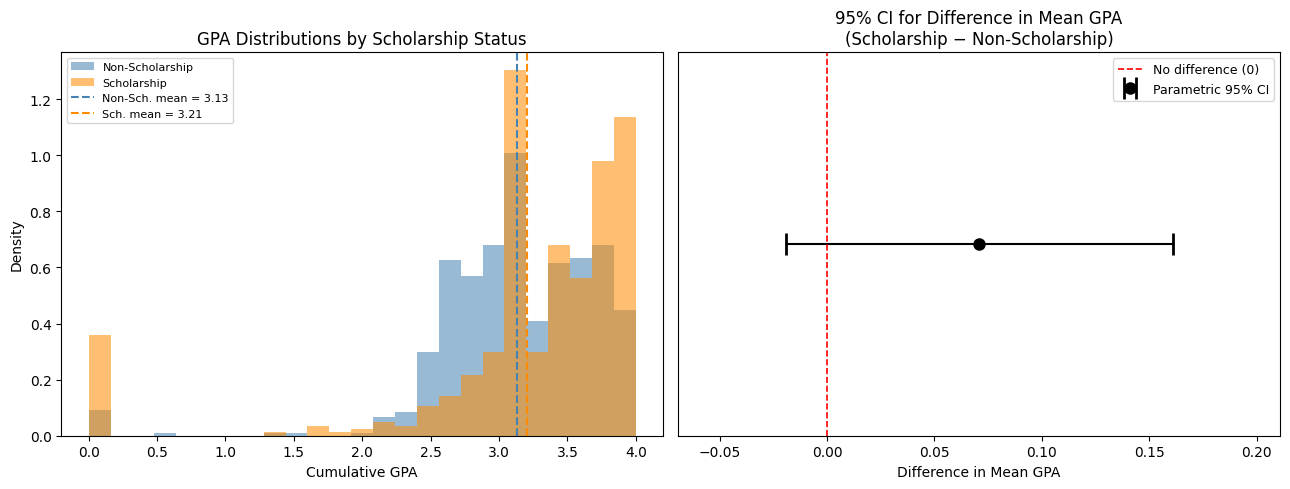

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: GPA distributions for both groups
ax = axes[0]
ax.hist(non_scholarship, bins=25, alpha=0.55, density=True, label='Non-Scholarship', color='steelblue')
ax.hist(scholarship, bins=25, alpha=0.55, density=True, label='Scholarship', color='darkorange')
ax.axvline(non_scholarship.mean(), color='steelblue', linestyle='--', linewidth=1.5, label=f'Non-Sch. mean = {non_scholarship.mean():.2f}')
ax.axvline(scholarship.mean(), color='darkorange', linestyle='--', linewidth=1.5, label=f'Sch. mean = {scholarship.mean():.2f}')
ax.set_title('GPA Distributions by Scholarship Status')
ax.set_xlabel('Cumulative GPA')
ax.set_ylabel('Density')
ax.legend(fontsize=8)

# Right: CI plot for the difference in means
ax2 = axes[1]
ax2.errorbar(
    x=[mean_diff], y=[0],
    xerr=[[mean_diff - ci_low], [ci_high - mean_diff]],
    fmt='o', color='black', capsize=8, capthick=2, markersize=8, label='Parametric 95% CI'
)
ax2.axvline(0, color='red', linestyle='--', linewidth=1.2, label='No difference (0)')
ax2.set_title('95% CI for Difference in Mean GPA\n(Scholarship − Non-Scholarship)')
ax2.set_xlabel('Difference in Mean GPA')
ax2.set_yticks([])
ax2.legend(fontsize=9)
ax2.set_xlim(ci_low - 0.05, ci_high + 0.05)

plt.tight_layout()
plt.show()

#### Interpretation of Normal Approximation CI

The 95% CI gives a plausible range for the **true population difference** in mean GPA between scholarship and non-scholarship students. If the interval does not include 0, the observed difference is unlikely to be explained by chance alone. If it includes 0, we cannot rule out that the true population difference is zero.

The width of the interval reflects **uncertainty due to sampling** — with a larger or more representative sample we would expect a narrower interval.

### Bootstrap Confidence Interval

The normal approximation CI relies on the CLT holding for our sample sizes. A **bootstrap CI** makes no distributional assumptions at all — it estimates the sampling distribution directly by resampling from the data with replacement.

If the two intervals agree closely, it gives us additional confidence in the result.

In [12]:
# --- Bootstrap confidence interval ---

np.random.seed(42)
n_bootstrap = 5000
bootstrap_diffs = np.empty(n_bootstrap)

for i in range(n_bootstrap):
    # Resample with replacement from each group
    boot_s  = np.random.choice(scholarship, size=n_s, replace=True)
    boot_ns = np.random.choice(non_scholarship, size=n_ns, replace=True)
    bootstrap_diffs[i] = boot_s.mean() - boot_ns.mean()

boot_ci_low, boot_ci_high = np.percentile(bootstrap_diffs, [2.5, 97.5])

print(f"Bootstrap mean of differences:     {bootstrap_diffs.mean():.4f}")
print(f"95% Bootstrap CI: ({boot_ci_low:.4f}, {boot_ci_high:.4f})")
print()
print(f"Parametric CI:    ({ci_low:.4f}, {ci_high:.4f})")
print(f"Bootstrap CI:     ({boot_ci_low:.4f}, {boot_ci_high:.4f})")

Bootstrap mean of differences:     0.0708
95% Bootstrap CI: (-0.0197, 0.1575)

Parametric CI:    (-0.0192, 0.1608)
Bootstrap CI:     (-0.0197, 0.1575)


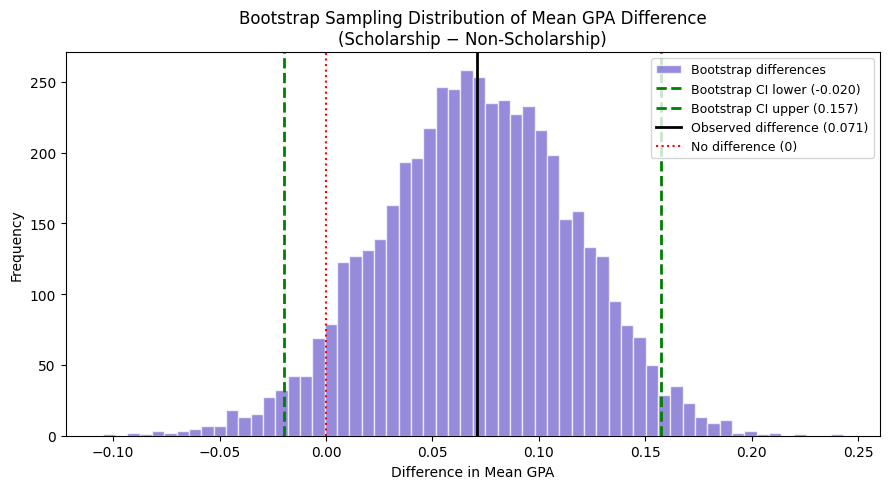

In [13]:
# Visualize the bootstrap sampling distribution
plt.figure(figsize=(9, 5))
plt.hist(bootstrap_diffs, bins=60, color='slateblue', alpha=0.7, edgecolor='white', label='Bootstrap differences')
plt.axvline(boot_ci_low,  color='green', linestyle='--', linewidth=2, label=f'Bootstrap CI lower ({boot_ci_low:.3f})')
plt.axvline(boot_ci_high, color='green', linestyle='--', linewidth=2, label=f'Bootstrap CI upper ({boot_ci_high:.3f})')
plt.axvline(mean_diff,    color='black', linestyle='-',  linewidth=2, label=f'Observed difference ({mean_diff:.3f})')
plt.axvline(0,            color='red',   linestyle=':',  linewidth=1.5, label='No difference (0)')
plt.title('Bootstrap Sampling Distribution of Mean GPA Difference\n(Scholarship − Non-Scholarship)')
plt.xlabel('Difference in Mean GPA')
plt.ylabel('Frequency')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

#### Interpretation of Bootstrap CI

The histogram shows the **bootstrap sampling distribution** — a simulated picture of how much the estimated mean GPA difference could vary across different random samples. The green dashed lines mark the 2.5th and 97.5th percentiles, forming the 95% bootstrap CI. The close agreement between the parametric CI and the bootstrap CI strengthens our conclusion: neither approach is sensitive to assumptions the other might be violating.

### What Uncertainty Means Here

Frequentist inference quantifies **uncertainty due to random sampling**. Our dataset is a snapshot of students from one institution; we want to draw conclusions about all students in the broader population. The confidence intervals capture that uncertainty.

The observed difference is small in absolute terms (~0.07 GPA points). Both CIs span a range that includes zero, meaning the data are consistent with there being no real difference in the population. Statistical significance and practical significance are not the same thing — the frequentist framework helps us resist over-interpreting a small observed difference in a finite sample as a definitive truth about the population.

In [14]:
# Final summary printout
print("=" * 60)
print("FREQUENTIST INFERENCE SUMMARY")
print("=" * 60)
print(f"Observed difference (scholarship - non-scholarship):  {mean_diff:+.4f} GPA points")
print()
print(f"95% Normal Approximation CI:  ({ci_low:.4f}, {ci_high:.4f})")
print(f"95% Bootstrap CI:             ({boot_ci_low:.4f}, {boot_ci_high:.4f})")
print()
if ci_low < 0 < ci_high:
    print("Conclusion: Both CIs contain 0 — we cannot rule out that the true")
    print("difference in population mean GPA is zero.")
else:
    print("Conclusion: Both CIs exclude 0 — statistically significant difference.")

FREQUENTIST INFERENCE SUMMARY
Observed difference (scholarship - non-scholarship):  +0.0708 GPA points

95% Normal Approximation CI:  (-0.0192, 0.1608)
95% Bootstrap CI:             (-0.0197, 0.1575)

Conclusion: Both CIs contain 0 — we cannot rule out that the true
difference in population mean GPA is zero.
